# Vowel recognition you can actually put on an FPGA

We are going to build this, one box at a time:

```
mic --> [gate] --> [frame] --> [window] --> [FFT] --> [mel filters] --> [log] --> [DCT] --> MFCCs
                                                                            |                 |
                                                             (HD rung: log-Mel) ---> [classifier] --> "ee"
```

**The rule that decides every design choice below:** an FPGA is good at adding, shifting, comparing, small
multiplies, and looking things up in a table. It is bad at dividing, and it has no `cos()`, `log()` or
floating point unless you build one. So every box has to be one of the good things.

**Where this sits in Assignment 2.** Frame, window, FFT and the Mel filters with a log are the audio ladder
up to R-A4 (24 log-Mel energies). The DCT that turns them into MFCCs is the *Extras* step. The classifier the
assignment provides is a nearest-template one (the *Provided Classifier* slide); the decision tree at the end
of this notebook is a second kind you may build for Extras, and it is worth seeing because a trained tree
**is already hardware**.

We use floats here on the PC to *understand* the algorithm. The last section shows what changes when it becomes
hardware. Run the cells in order. You do not need a microphone: there is a fake one.

## Setup

The numbers are the assignment's: 12 kHz after the Lesson 4 decimation, 1024-sample frames (85 ms), 24 Mel
bands, and the first 13 cosine coefficients of which we keep c₁…c₁₂.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = os.environ["OPENBLAS_NUM_THREADS"] = "1"   # one BLAS thread: Ed's kernel has little memory
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
plt.rcParams.update({"figure.dpi": 140, "font.size": 7, "axes.titlesize": 6.5, "lines.linewidth": 1.1, "axes.linewidth": 0.55,
                     "xtick.major.width": 0.55, "ytick.major.width": 0.55})   # Ed shows 950 px: every figure below is 6.8 in wide

SR    = 12000     # sample rate after decimation: 6 kHz of bandwidth, plenty for a vowel
FRAME = 1024      # 85 ms per frame. A power of two, so the FFT is the Lesson 4 one.
HOP   = 512       # 43 ms step, so frames overlap by half
NMEL  = 24        # how many mel filters
NCEP  = 13        # cosine coefficients c0..c12; we keep c1..c12
FMIN, FMAX = 100, 6000

print("frame = %.1f ms, hop = %.1f ms, %d FFT bins %.2f Hz apart" % (1000*FRAME/SR, 1000*HOP/SR, FRAME//2 + 1, SR/FRAME))

frame = 85.3 ms, hop = 42.7 ms, 513 FFT bins 11.72 Hz apart


## Step 0 — Some audio to play with

Real microphones are annoying to debug against, so we start with a **fake microphone**: a crude vowel
synthesiser that pushes a buzz through two resonant filters. That is roughly what your throat and mouth do:
vocal cords buzz at the pitch, the mouth's shape filters the buzz, and the two strongest resonances (the
**formants** F1 and F2) are what make *ee* differ from *ah*. It sounds robotic, but it has the property we
need: the four vowels really do differ in the way real ones do, and every fake speaker has a different pitch,
a different vocal tract and a different loudness.

> When you want real voices, the *Audio Ladder* notebook's `audio_model.py` loads 139 real speakers; the
> last section shows how.

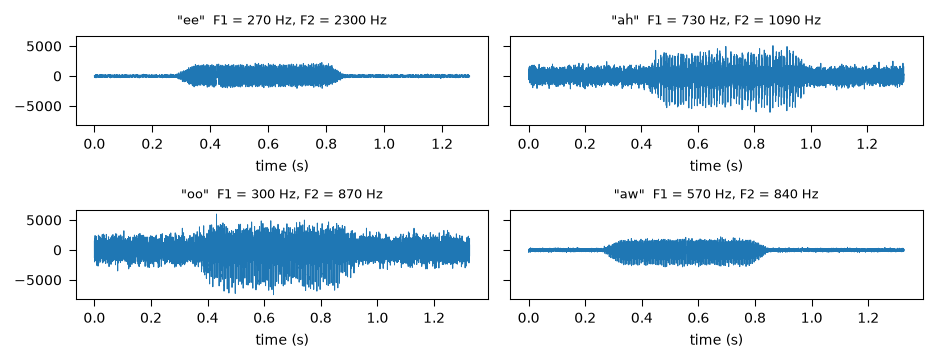

In [2]:
# --- the fake microphone -----------------------------------------------
# a vowel is a held buzz under two formants (F1, F2 in Hz: Peterson & Barney's men, roughly)
VOWELS = {"ee": (270, 2300), "ah": (730, 1090), "oo": (300, 870), "aw": (570, 840)}
LANES = list(VOWELS)                       # 0 = ee, 1 = ah, 2 = oo, 3 = aw: the four keys

def _resonate(exc, f1, f2):
    '''Push the excitation through two band-pass filters = two formants.'''
    out = np.zeros_like(exc)
    for f, gain in ((f1, 1.0), (f2, 0.6)):
        f  = float(np.clip(f, 150, SR/2 - 250))
        bw = 90 + 0.06*f
        b, a = butter(2, [max(30, f-bw)/(SR/2), min(SR/2-20, f+bw)/(SR/2)], btype="band")
        out += gain * lfilter(b, a, exc)
    return out

def fake_mic(vowel, rng, dur_ms=600):
    '''One noisy int16 recording of `vowel` held for dur_ms, with a random speaker, pitch and volume.'''
    f0     = rng.uniform(95, 220)      # pitch
    fscale = rng.uniform(0.85, 1.15)   # vocal tract length: moves both formants
    gain   = rng.uniform(0.15, 1.0)    # how loud, on purpose a 7x spread
    n      = int(SR*dur_ms/1000)
    exc, t = np.zeros(n), 0.0          # the buzz: one pulse per period, the period wobbling a little
    period = SR/f0
    while t < n:
        exc[int(t)] = 1.0; t += period*rng.uniform(.97, 1.03)
    exc += 0.02*rng.standard_normal(n)
    f1, f2 = VOWELS[vowel]
    drift = rng.uniform(0.96, 1.04, 2)  # the mouth is not quite still
    blocks = []
    for k in range(4):
        sl = slice(k*n//4, (k+1)*n//4); u = (k + .5)/4
        blocks.append(_resonate(exc[sl], f1*fscale*(1 + (drift[0]-1)*u), f2*fscale*(1 + (drift[1]-1)*u)))
    seg = np.concatenate(blocks)
    seg /= np.sqrt((seg**2).mean()) + 1e-9
    env = np.ones(len(seg)); r = len(seg)//8
    env[:r] = np.linspace(0, 1, r); env[-r:] = np.linspace(1, 0, r)
    sig = gain * seg*env/(np.abs(seg).max() + 1e-9)
    sig = np.concatenate([np.zeros(int(SR*rng.uniform(.20, .45))), sig, np.zeros(int(SR*rng.uniform(.30, .50)))])
    sig = sig + rng.standard_normal(len(sig))*gain*10**(-rng.uniform(15, 30)/20)     # the room, 15-30 dB down
    return np.round(sig*12000).astype(np.int16)

rng = np.random.default_rng(0)
demo = {v: fake_mic(v, rng) for v in VOWELS}

fig, ax = plt.subplots(2, 2, figsize=(6.7, 2.6), sharey=True)
for a, v in zip(ax.ravel(), VOWELS):
    a.plot(np.arange(len(demo[v]))/SR, demo[v], lw=.5)
    a.set_title(f'"{v}"  F1 = {VOWELS[v][0]} Hz, F2 = {VOWELS[v][1]} Hz'); a.set_xlabel("time (s)")
plt.tight_layout(); plt.show()

## Step 1 — Chop the audio into frames

Speech changes constantly, so there is no such thing as "the spectrum of a word". But over **85 ms** a held
vowel barely moves, so an 85 ms slice is close enough to unchanging that a spectrum means something.

We take 1024 samples at a time, stepping forward 512 samples so consecutive frames overlap by half. Overlap
matters: without it, a sound landing on a frame boundary gets cut in half and smeared.

**In hardware:** the Lesson 4 FFT input buffer, a 1024-word FIFO and a counter. Nothing else. (The Lesson 4
pipeline hops a whole frame; overlapping frames only changes how often a frame arrives.)

audio samples: 15960 -> frames: (30, 1024)


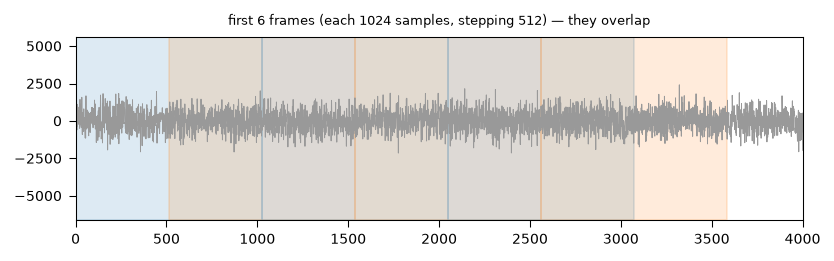

In [3]:
def frames_of(x, frame=FRAME, hop=HOP):
    '''Slice a signal into overlapping frames -> shape (n_frames, frame).'''
    n = 1 + max(0, (len(x) - frame)//hop)
    idx = np.arange(frame)[None, :] + hop*np.arange(n)[:, None]
    return np.asarray(x, dtype=float)[idx]

F = frames_of(demo["ah"])
print("audio samples:", len(demo["ah"]), "-> frames:", F.shape)

plt.figure(figsize=(6.7, 1.7))
plt.plot(demo["ah"], lw=.5, color="0.6")
for i in range(0, 6):
    plt.axvspan(i*HOP, i*HOP + FRAME, alpha=.15, color="C%d" % (i % 2))
plt.title("first 6 frames (each 1024 samples, stepping 512) — they overlap")
plt.xlim(0, 4000); plt.show()

## Step 2 — Window each frame

The FFT secretly assumes the 1024 samples repeat forever. If the frame starts and ends at different values,
that invented jump generates fake high frequencies: **spectral leakage**.

The fix is to fade each frame in and out so both ends sit near zero. The assignment's word for the fade is
the **Hamming window**. The plot below shows why it matters: same pure tone, one clean peak versus a smeared
mess.

**In hardware:** a 1024-entry ROM of constants and one multiplier. `window_function.sv` in the pitch-detect
workspace is a passthrough (a rectangular window); this is what it should become.

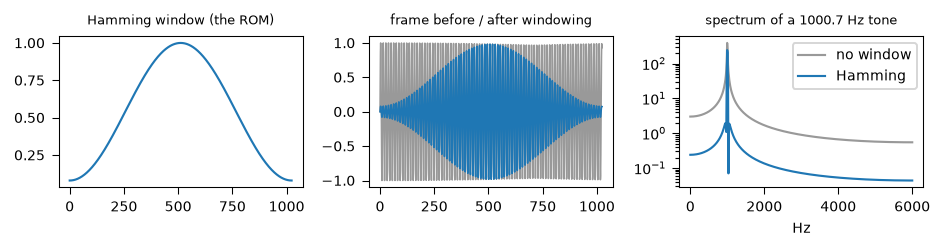

In [4]:
WIN = 0.54 - 0.46*np.cos(2*np.pi*np.arange(FRAME)/(FRAME - 1))   # Hamming

tone = np.sin(2*np.pi*1000.7*np.arange(FRAME)/SR)               # not a whole number of cycles
raw_spec = np.abs(np.fft.rfft(tone))
win_spec = np.abs(np.fft.rfft(tone*WIN))
freqs = np.fft.rfftfreq(FRAME, 1/SR)

fig, ax = plt.subplots(1, 3, figsize=(6.7, 1.8))
ax[0].plot(WIN); ax[0].set_title("Hamming window (the ROM)")
ax[1].plot(tone, color="0.6", lw=.8); ax[1].plot(tone*WIN, lw=.8)
ax[1].set_title("frame before / after windowing")
ax[2].semilogy(freqs, raw_spec + 1e-9, color="0.6", label="no window")
ax[2].semilogy(freqs, win_spec + 1e-9, label="Hamming")
ax[2].set_title("spectrum of a 1000.7 Hz tone"); ax[2].set_xlabel("Hz")
ax[2].legend()
plt.tight_layout(); plt.show()

## Step 3 — FFT, then throw away the phase

The FFT turns 1024 time samples into 513 frequency bins. Each bin is a complex number: *how much* of that
frequency, and *when* it peaked (phase).

For recognising vowels, phase is useless: *ee* said a millisecond later is still *ee*. So we keep only the
power, |X|² = re² + im², and drop the phase entirely.

**In hardware:** the 1024-point FFT is the biggest block in the design, and Lesson 4 gave it to you, with
`fft_mag_sq` behind it. Note that it never takes a square root: |X|² is what the pipeline has, and the log in
Step 5 turns the square into a factor of two, which is a shift.

frames x bins: (30, 513)  (513 bins, 11.72 Hz apart)


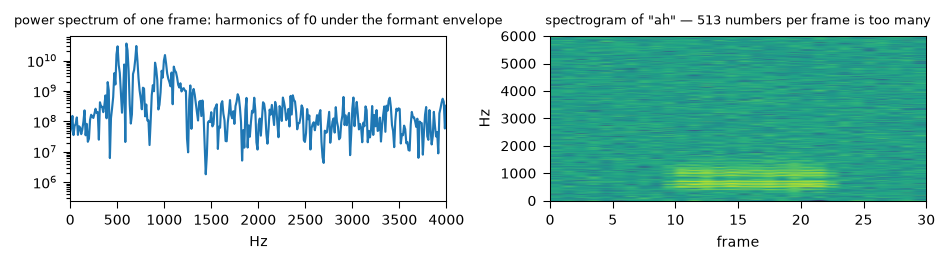

In [5]:
def spectrum_of(x):
    '''(n_frames, 513) power spectra |X_k|^2 of the windowed frames'''
    return np.abs(np.fft.rfft(frames_of(x)*WIN, axis=1))**2

S = spectrum_of(demo["ah"])
print("frames x bins:", S.shape, " (513 bins, %.2f Hz apart)" % (SR/FRAME))

fig, ax = plt.subplots(1, 2, figsize=(6.7, 1.9))
ax[0].semilogy(freqs, S[10] + 1e-9); ax[0].set_title("power spectrum of one frame: harmonics of f0 under the formant envelope")
ax[0].set_xlabel("Hz"); ax[0].set_xlim(0, 4000)
ax[1].imshow(np.log(S.T + 1e-6), origin="lower", aspect="auto", extent=[0, len(S), 0, SR/2])
ax[1].set_title('spectrogram of "ah" — 513 numbers per frame is too many')
ax[1].set_ylabel("Hz"); ax[1].set_xlabel("frame")
plt.tight_layout(); plt.show()

## Step 4 — Mel filters: squash 513 bins down to 24

513 numbers per frame is far too many to compare against a template or feed a tree, and most of them are
redundant anyway. So we sum the bins into **24 overlapping triangular bands**.

The bands are narrow at low frequency and wide at high frequency, because that is how your ear works: you
can easily hear 200 Hz vs 300 Hz, but 3000 Hz vs 3100 Hz sound identical. That spacing is the *mel scale*.
Vowels are distinguished by low-frequency detail (F1 and F2 both sit below 2.5 kHz), so that is where we spend
our resolution. Compare the Credit rung's eight *equal* bands: 750 Hz each, three of them below F2.

**In hardware:** each bin belongs to two triangles, with two weights. A ROM of 929 weights, walked once per
frame with one multiplier and an accumulator per band. The weights are constants: nothing is computed at run time.

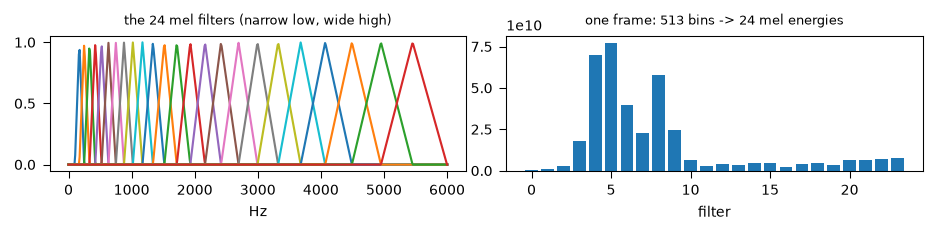

non-zero weights in the ROM: 954


In [6]:
def hz2mel(f): return 2595*np.log10(1 + f/700)
def mel2hz(m): return 700*(10**(m/2595) - 1)

edges   = mel2hz(np.linspace(hz2mel(FMIN), hz2mel(FMAX), NMEL + 2))
centres = edges*FRAME/SR                      # in FFT-bin units

MEL = np.zeros((NMEL, FRAME//2 + 1))
for m in range(NMEL):
    lo, ctr, hi = centres[m], centres[m+1], centres[m+2]
    for b in range(FRAME//2 + 1):
        if   lo < b <= ctr: MEL[m, b] = (b - lo)/(ctr - lo)     # ramp up
        elif ctr < b <  hi: MEL[m, b] = (hi - b)/(hi - ctr)     # ramp down

fig, ax = plt.subplots(1, 2, figsize=(6.7, 1.8))
for m in range(NMEL):
    ax[0].plot(freqs, MEL[m])
ax[0].set_title("the 24 mel filters (narrow low, wide high)"); ax[0].set_xlabel("Hz")
ax[1].bar(range(NMEL), S[10] @ MEL.T)
ax[1].set_title("one frame: 513 bins -> 24 mel energies"); ax[1].set_xlabel("filter")
plt.tight_layout(); plt.show()
print("non-zero weights in the ROM:", int((MEL > 0).sum()))

## Step 5 — Take the log

Two reasons, and the second one is the one people forget.

1. **Dynamic range.** The first formant can be thousands of times stronger than the top band. The log
   compresses that so the quiet bands still count.
2. **Volume stops mattering.** Speak twice as loudly and every mel energy quadruples (it is a power). After a
   log₂, quadrupling becomes *"add 2 to all 24"*: it changes the offset, not the shape. That is what makes the
   next step give us volume-independent features for free, and it is exactly why the Distinction rung divides
   by the total and the HD rung subtracts the mean.

The cell below proves point 2 numerically.

log2-mel of frame 10, quiet:
 [29.01 30.03 31.34 34.07 36.03 36.17 35.21 34.4  35.75 34.51 32.65 31.29 31.92 31.75 32.09
 32.17 31.17 31.91 32.05 31.75 32.57 32.64 32.72 32.87]
log2-mel of frame 10, loud :
 [35.01 36.03 37.34 40.07 42.03 42.17 41.21 40.4  41.75 40.51 38.65 37.29 37.92 37.75 38.09
 38.17 37.17 37.91 38.05 37.75 38.57 38.64 38.72 38.87]
difference                 :
 [6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6.]

-> 8x louder (64x the power) just adds a constant (log2 64 = 6) to every band.


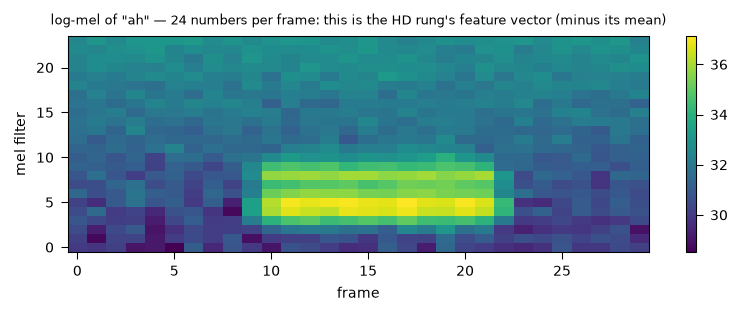

In [7]:
quiet = demo["ah"]
loud  = (demo["ah"].astype(float)*8)          # +18 dB, same vowel

lm_q = np.log2(np.maximum(spectrum_of(quiet) @ MEL.T, 1e-10))
lm_l = np.log2(np.maximum(spectrum_of(loud)  @ MEL.T, 1e-10))

np.set_printoptions(linewidth=96, precision=2, suppress=True)
print("log2-mel of frame 10, quiet:\n", lm_q[10])
print("log2-mel of frame 10, loud :\n", lm_l[10])
print("difference                 :\n", lm_l[10] - lm_q[10])
print("\n-> 8x louder (64x the power) just adds a constant (log2 64 = %.0f) to every band." % np.log2(64))

plt.figure(figsize=(6.7, 2.0))
plt.imshow(lm_q.T, origin="lower", aspect="auto")
plt.title('log-mel of "ah" — 24 numbers per frame: this is the HD rung\'s feature vector (minus its mean)'); plt.ylabel("mel filter")
plt.xlabel("frame"); plt.colorbar(); plt.show()

## Step 6 — DCT: the last squeeze, and where the volume goes

The 24 log-mel numbers are still heavily correlated: neighbouring filters overlap, so they rise and fall
together. The DCT re-describes the *shape* of those 24 numbers as a sum of cosine ripples, and keeps the 13
slowest ones. Those are the **MFCCs**.

Here is the payoff from Step 5. A volume change adds the same constant to all 24 log-mel values. A flat offset
is the slowest possible shape, so the DCT dumps it **entirely into `c0`**. Which means:

> `c0` is loudness. `c1`…`c12` are the *shape* of the spectrum, and are already volume-independent.

So we throw `c0` away and keep 12 numbers. (Subtracting the mean of the 24 log-mel values, as the HD rung
does, removes exactly the same thing without a DCT: that is why log-Mel-minus-mean is already loudness-free,
and why MFCC is an Extra rather than a rung. What the DCT adds is the *smoothing*: the fine harmonic ripple
lives in the fast cosines we drop.)

**In hardware:** a 13×24 table of constants, 312 multiply-accumulates per frame, one multiplier. The cosines
are baked into the ROM.

c0..c12 shift when we make it 8x louder:
[144.  -0.  -0.   0.  -0.  -0.  -0.  -0.   0.  -0.  -0.   0.  -0.]

-> all the volume landed in c0. c1..c12 did not move.


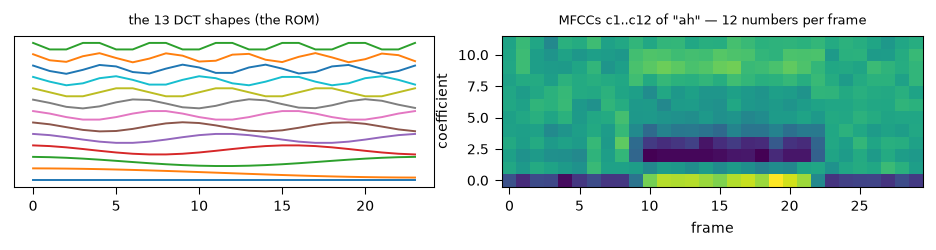

In [8]:
k, m = np.arange(NCEP)[:, None], np.arange(NMEL)[None, :]
DCT = np.cos(np.pi*k*(2*m + 1)/(2*NMEL))        # 13 x 24 constant table

def mfcc_of(x):
    '''audio -> (n_frames, 13) MFCCs c0..c12. This is the whole front end.'''
    logmel = np.log2(np.maximum(spectrum_of(x) @ MEL.T, 1e-10))
    return logmel @ DCT.T

Mq, Ml = mfcc_of(quiet), mfcc_of(loud)
print("c0..c12 shift when we make it 8x louder:")
print((Ml - Mq)[5:15].mean(0))
print("\n-> all the volume landed in c0. c1..c12 did not move.")

fig, ax = plt.subplots(1, 2, figsize=(6.7, 1.8))
for i in range(NCEP):
    ax[0].plot(DCT[i] + 2.5*i, lw=1)
ax[0].set_title("the 13 DCT shapes (the ROM)"); ax[0].set_yticks([])
ax[1].imshow(Mq[:, 1:].T, origin="lower", aspect="auto")
ax[1].set_title('MFCCs c1..c12 of "ah" — 12 numbers per frame')
ax[1].set_xlabel("frame"); ax[1].set_ylabel("coefficient")
plt.tight_layout(); plt.show()

## Step 7 — Finding the voice: the gate. This is the important one.

Your recording is mostly silence. If you classify every frame, most of what you classify is *room noise*, and
the room is not a vowel. Step 9 measures this for you: same features, same classifiers, the only difference
being whether we gate first. On the fake data it is the single biggest factor in the whole notebook, bigger
than any feature.

Two ideas make it work:

- **A noise floor that falls fast and rises slowly.** `floor = min(energy, floor + floor/64 + 1)`. Because it
  only ever creeps upward, speech cannot drag it up, so it keeps measuring the *room* even if the speaker starts
  talking immediately. (Averaging the first N frames to get the noise level fails exactly then.) A held vowel
  cannot close the gate on itself.
- **Hysteresis.** Require 2 loud frames to open, but 8 quiet frames to close. Otherwise a brief dip inside a
  vowel ends it early.

**In hardware:** an absolute value, an accumulator, two counters, a comparator. The assignment's gate does this
per *sample* rather than per frame, with the same fall-fast-rise-slow floor and a 12 dB margin; the *Gate and
Level in dB* slide has it, and the *Audio Ladder* notebook models it exactly. The frame version here is enough
to see the idea.

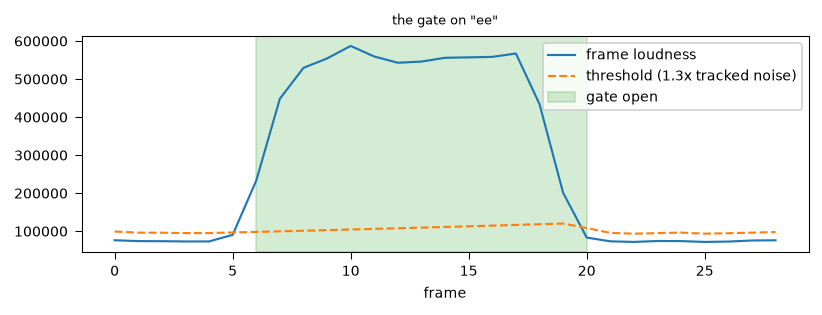

voice runs from frame 6 to 20 (0.60 s of the 1.29 s clip)


In [9]:
def gate(x, on_run=2, off_run=8):
    '''Return (first_frame, last_frame) of the voice, or None.'''
    e = np.abs(frames_of(x)).sum(axis=1)      # loudness per frame: just |x| summed
    if len(e) < 4: return None

    floor, f = np.zeros(len(e)), e[0]         # noise tracker: drops fast, creeps up
    for i, v in enumerate(e):
        f = min(v, f + f/64 + 1)
        floor[i] = f

    loud = e > 1.3*floor + 64                 # the threshold: the margin

    start, run = None, 0                      # need on_run loud frames to open
    for i, a in enumerate(loud):
        run = run + 1 if a else 0
        if run >= on_run: start = i - on_run + 1; break
    if start is None: return None

    end, run = len(loud), 0                   # need off_run quiet frames to close
    for i in range(start, len(loud)):
        run = run + 1 if not loud[i] else 0
        if run >= off_run: end = i - off_run + 1; break
    return (start, end) if end - start >= 3 else None

x = demo["ee"]
e = np.abs(frames_of(x)).sum(axis=1)
s, en = gate(x)

plt.figure(figsize=(6.7, 2.0))
plt.plot(e, label="frame loudness")
f, fl = e[0], []
for v in e:
    f = min(v, f + f/64 + 1); fl.append(f)
plt.plot(np.array(fl)*1.3 + 64, "--", label="threshold (1.3x tracked noise)")
plt.axvspan(s, en, alpha=.2, color="C2", label="gate open")
plt.legend(); plt.title('the gate on "ee"'); plt.xlabel("frame"); plt.show()
print("voice runs from frame %d to %d (%.2f s of the %.2f s clip)" % (s, en, (en-s)*HOP/SR, len(x)/SR))

## Step 8 — Every gated frame is an example

Now put it together: gate, take the MFCCs of just those frames, drop `c0`. Each frame is one 12-number
example. There is no averaging over the utterance: on the FPGA the classifier decides **per frame**, once
every 85 ms, and the provided classifier's vote smooths the answers afterwards. A held vowel gives a dozen
examples; forty recordings give a few hundred per vowel.

In [10]:
def features_of(x):
    '''One recording -> (n_gated_frames, 12): c1..c12 of every frame with the gate open.'''
    Mf = mfcc_of(x)
    seg = gate(x)
    s, e = seg if seg is not None else (0, len(Mf))   # fall back to the whole clip
    return Mf[s:min(e, len(Mf)), 1:]

FEATNAMES = [f"c{i}" for i in range(1, NCEP)]
for v in VOWELS:
    Fv = features_of(demo[v])
    print("%-3s %2d frames, mean c1..c12:" % (v, len(Fv)), np.round(Fv.mean(0), 1))

ee  14 frames, mean c1..c12: [ 19.3   0.1  29.1  13.  -15.4   2.7   6.9  -6.5  -3.2   3.7   0.5   1.5]
ah  12 frames, mean c1..c12: [  9.9  -3.3 -20.  -16.   -7.2  -2.9  -2.4  -2.1   1.6   4.7   3.6   1.5]
oo  12 frames, mean c1..c12: [12.5  8.9 -5.  -2.2  0.1  2.6 -1.4 -5.5 -6.1 -2.6  1.1  2.7]
aw  15 frames, mean c1..c12: [ 27.5  -3.6 -22.9 -15.1  -8.5  -5.3  -6.1  -5.9  -3.9  -0.    3.9   4.6]


## Step 9 — Collect data and train two classifiers

Forty fake recordings per vowel. The split is **by recording**: frames from a recording you trained on never
appear in the test set. (Splitting by frame would test on the training data's near-duplicates and flatter
you: if you ever see 0.99 on real voices, this is the first thing to suspect.)

Two classifiers on the same features:

- **Nearest template**, the one the assignment provides: four templates per vowel from k-means, the sum of
  absolute differences, and the nearest wins. A subtract, an absolute value and an add per feature; no
  multiplier. Its rejection rule and vote are in the *Provided Classifier* slide; here we skip them.
- **A decision tree**, because a trained tree **is already hardware**: every node is one comparison of one
  feature against a constant. No multiplies, no memory, no floating point. The forty lines below are the
  whole learning algorithm (CART with the Gini impurity), so there is nothing to install.

In [11]:
class Tree:
    '''A CART decision tree: at every node, the (feature, threshold) split that most reduces the Gini impurity
    of the two halves; a leaf holds the majority class. max_depth and min_leaf keep it small.'''
    def __init__(self, max_depth=6, min_leaf=5): self.max_depth, self.min_leaf = max_depth, min_leaf

    def fit(self, X, y):
        self.nc = int(y.max()) + 1; self.root = self._grow(np.asarray(X, float), np.asarray(y), 0); return self

    def _gini(self, counts): p = counts/max(counts.sum(), 1); return 1 - (p**2).sum()

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.nc)
        node = {"n": len(y), "class": int(counts.argmax()), "counts": counts}
        if depth >= self.max_depth or len(y) < 2*self.min_leaf or counts.max() == len(y): return node
        best = (self._gini(counts), None, None); onehot = np.eye(self.nc)[y]
        for j in range(X.shape[1]):                                       # every feature ...
            order = np.argsort(X[:, j], kind="stable"); xs = X[order, j]
            left = np.cumsum(onehot[order], axis=0)[:-1]                  # class counts left of each cut
            nl = np.arange(1, len(y))[:, None]; right = counts - left; nr = len(y) - nl
            g = (nl[:, 0]*(1 - ((left/nl)**2).sum(1)) + nr[:, 0]*(1 - ((right/nr)**2).sum(1)))/len(y)
            ok = (xs[1:] != xs[:-1]) & (nl[:, 0] >= self.min_leaf) & (nr[:, 0] >= self.min_leaf)
            g[~ok] = np.inf; i = int(np.argmin(g))                        # ... every cut, vectorised
            if g[i] < best[0]: best = (g[i], j, (xs[i] + xs[i+1])/2)
        if best[1] is None: return node
        j, thr = best[1], best[2]; go = X[:, j] <= thr
        node.update(feature=j, threshold=thr, left=self._grow(X[go], y[go], depth+1), right=self._grow(X[~go], y[~go], depth+1))
        return node

    def predict(self, X):
        out = []
        for x in np.asarray(X, float):
            n = self.root
            while "feature" in n: n = n["left"] if x[n["feature"]] <= n["threshold"] else n["right"]
            out.append(n["class"])
        return np.array(out)

    def n_nodes(self):
        def cnt(n): return 1 + (cnt(n["left"]) + cnt(n["right"]) if "feature" in n else 0)
        return cnt(self.root)

def templates_of(X, nt=4, seed=0, iters=15):
    '''k-means with the sum of absolute differences (the medians minimise it): nt templates for one class'''
    rng = np.random.default_rng(seed); X = np.asarray(X, float)
    cen = X[rng.choice(len(X), nt, replace=False)]
    for _ in range(iters):
        a = np.abs(X[:, None, :] - cen[None, :, :]).sum(axis=2).argmin(axis=1)
        for t in range(nt):
            if np.any(a == t): cen[t] = np.median(X[a == t], axis=0)
    return cen

def nearest_template(X, T):
    '''T: {class: (nt, D)}. The provided classifier's rule without the reject and the vote.'''
    d = np.stack([np.abs(np.asarray(X, float)[:, None, :] - T[c][None, :, :]).sum(axis=2).min(axis=1) for c in sorted(T)], axis=1)
    return d.argmin(axis=1)

training frames: (1725, 12)  test frames: (719, 12)
nearest template: train 0.87  test 0.83
decision tree   : train 0.88  test 0.87   (27 nodes)

without the gate (every frame, silence included): nearest template test 0.57, tree test 0.56


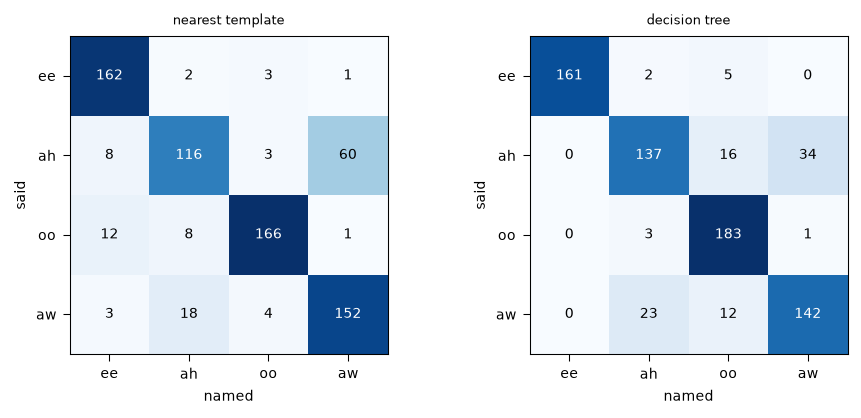

In [12]:
rng = np.random.default_rng(1)
clips = {v: [fake_mic(v, rng) for _ in range(40)] for v in VOWELS}          # our recordings
train_ids, test_ids = range(0, 28), range(28, 40)                          # split by RECORDING

def dataset(ids, feat=features_of):
    X = [feat(clips[v][i]) for v in VOWELS for i in ids]
    y = [np.full(len(f), LANES.index(v)) for v, f in zip([v for v in VOWELS for i in ids], X)]
    return np.vstack(X), np.concatenate(y)

Xtr, ytr = dataset(train_ids); Xte, yte = dataset(test_ids)
print("training frames:", Xtr.shape, " test frames:", Xte.shape)

T = {c: templates_of(Xtr[ytr == c]) for c in range(4)}
tree = Tree(max_depth=6, min_leaf=30).fit(Xtr, ytr)
acc = lambda pred, y: (pred == y).mean()
print("nearest template: train %.2f  test %.2f" % (acc(nearest_template(Xtr, T), ytr), acc(nearest_template(Xte, T), yte)))
print("decision tree   : train %.2f  test %.2f   (%d nodes)" % (acc(tree.predict(Xtr), ytr), acc(tree.predict(Xte), yte), tree.n_nodes()))

# --- does the gate actually matter? measure it, don't take my word ---
def features_no_gate(x): return mfcc_of(x)[:, 1:]                          # every frame, silence too
Xtr0, ytr0 = dataset(train_ids, features_no_gate); Xte0, yte0 = dataset(test_ids, features_no_gate)
T0 = {c: templates_of(Xtr0[ytr0 == c]) for c in range(4)}
print("\nwithout the gate (every frame, silence included): nearest template test %.2f, tree test %.2f"
      % (acc(nearest_template(Xte0, T0), yte0), acc(Tree(6, 5).fit(Xtr0, ytr0).predict(Xte0), yte0)))

def confusion(y, pred):
    cm = np.zeros((4, 4), int)
    for t, p in zip(y, pred): cm[t, p] += 1
    return cm
fig, axs = plt.subplots(1, 2, figsize=(6.7, 3.0))
for a, (name, pred) in zip(axs, [("nearest template", nearest_template(Xte, T)), ("decision tree", tree.predict(Xte))]):
    cm = confusion(yte, pred); a.imshow(cm, cmap="Blues")
    a.set_xticks(range(4), LANES); a.set_yticks(range(4), LANES); a.set_xlabel("named"); a.set_ylabel("said"); a.set_title(name)
    for i in range(4):
        for j in range(4): a.text(j, i, cm[i, j], ha="center", va="center", color="w" if cm[i, j] > cm.max()/2 else "k")
plt.tight_layout(); plt.show()

> **What to expect on real voices.** The fake mic is cleaner and more consistent than a person, so accuracy
> here is flattering. On the real recordings (the *Audio Ladder* notebook, section 5) the same features give
> about 90 % on a voice that was enrolled and 65 to 85 % on one that was not, and the demo probes are designed
> to find the difference. If you get 0.99 on real data, be suspicious: you are probably testing on frames from
> the recordings you trained on.

### Look at the tree — this is your Verilog

`export_text` prints the logic you are about to build.

In [13]:
def export_text(tree, feat_names, labels):
    L = []
    def walk(n, d):
        pad = "|   "*d
        if "feature" not in n: L.append(f"{pad}|--- class: {labels[n['class']]}  ({n['n']} frames)"); return
        L.append(f"{pad}|--- {feat_names[n['feature']]} <= {n['threshold']:.2f}"); walk(n["left"], d+1)
        L.append(f"{pad}|--- {feat_names[n['feature']]} >  {n['threshold']:.2f}"); walk(n["right"], d+1)
    walk(tree.root, 0); return "\n".join(L)

print(export_text(tree, FEATNAMES, LANES))

|--- c3 <= 2.78
|   |--- c2 <= 5.84
|   |   |--- c2 <= -7.01
|   |   |   |--- c12 <= -0.18
|   |   |   |   |--- c11 <= 2.44
|   |   |   |   |   |--- c1 <= 22.17
|   |   |   |   |   |   |--- class: ah  (243 frames)
|   |   |   |   |   |--- c1 >  22.17
|   |   |   |   |   |   |--- class: ah  (30 frames)
|   |   |   |   |--- c11 >  2.44
|   |   |   |   |   |--- class: ah  (50 frames)
|   |   |   |--- c12 >  -0.18
|   |   |   |   |--- c11 <= 3.84
|   |   |   |   |   |--- class: ah  (47 frames)
|   |   |   |   |--- c11 >  3.84
|   |   |   |   |   |--- class: aw  (35 frames)
|   |   |--- c2 >  -7.01
|   |   |   |--- c5 <= -3.77
|   |   |   |   |--- c2 <= -5.38
|   |   |   |   |   |--- class: aw  (50 frames)
|   |   |   |   |--- c2 >  -5.38
|   |   |   |   |   |--- c5 <= -5.61
|   |   |   |   |   |   |--- class: aw  (263 frames)
|   |   |   |   |   |--- c5 >  -5.61
|   |   |   |   |   |   |--- class: aw  (30 frames)
|   |   |   |--- c5 >  -3.77
|   |   |   |   |--- c9 <= -2.25
|   |   |   |  

## Step 10 — Turn the features into integers

Our 12 features are floats like `-3.87`. An FPGA would much rather compare integers, so multiply by 256 and
round. That is "Q8 fixed point": the bottom 8 bits are the fraction, and from the hardware's point of view it
is just an `int16`. (The provided classifier takes *unsigned* 16-bit features: add an offset as well, and say
which bits you kept in the report.)

Retrain on the integers and check we lost nothing.

In [14]:
Xq_tr, Xq_te = np.round(Xtr*256).astype(np.int32), np.round(Xte*256).astype(np.int32)
print("integer feature range: %d .. %d  (fits in int16: %s)" % (Xq_tr.min(), Xq_tr.max(), Xq_tr.min() >= -32768 and Xq_tr.max() <= 32767))

treeq = Tree(max_depth=6, min_leaf=30).fit(Xq_tr, ytr)
Tq = {c: templates_of(Xq_tr[ytr == c]) for c in range(4)}
print("integer features, test accuracy: tree %.2f, nearest template %.2f" % (acc(treeq.predict(Xq_te), yte), acc(nearest_template(Xq_te, Tq), yte)))
print("(compare with the float numbers from Step 9 - they should be the same)")

integer feature range: -10603 .. 12969  (fits in int16: True)
integer features, test accuracy: tree 0.87, nearest template 0.83
(compare with the float numbers from Step 9 - they should be the same)


## Step 11 — Emit the Verilog

Each tree node becomes one `if`. One extra trick: the split rule reduces *impurity*, not error, so it happily
creates branches where both sides predict the same class. Those cost comparators and change nothing, so we
collapse them first; the printout says how many were saved.

This module has the provided classifier's input (`f`, twelve 16-bit words) and a 2-bit class out, so it drops
in where `classifier.sv` sits, minus the reject and the vote. Retraining it means a recompile, exactly as a new
`templates.svh` does.

In [15]:
def export_verilog(tree, labels, feat_names, name="vowel_tree"):
    same = {}                                    # subtree that agrees -> its class
    def resolve(n):
        if "feature" not in n: same[id(n)] = n["class"]
        else:
            a, b = resolve(n["left"]), resolve(n["right"])
            same[id(n)] = a if (a is not None and a == b) else None
        return same[id(n)]
    resolve(tree.root)

    nf, ncmp = len(feat_names), [0]
    L = ["// generated from the decision tree -- do not edit by hand",
         "// classes: " + ", ".join(f"{i}={l}" for i, l in enumerate(labels)),
         f"module {name} (",
         f"    input  wire signed [15:0] f [0:{nf-1}],   // Q8 features",
         f"    output reg  [{max(1, (len(labels)-1).bit_length())-1}:0] cls",
         ");", "    always @* begin"]
    def walk(n, d):
        pad = "    "*d
        if same[id(n)] is not None:
            L.append(f"{pad}cls = {same[id(n)]};  // {labels[same[id(n)]]}"); return
        ncmp[0] += 1
        fi, thr = n["feature"], int(np.floor(n["threshold"]))
        L.append(f"{pad}if (f[{fi}] <= {thr}) begin   // {feat_names[fi]}")
        walk(n["left"], d+1)
        L.append(f"{pad}end else begin")
        walk(n["right"], d+1)
        L.append(f"{pad}end")
    walk(tree.root, 2)
    L += ["    end", "endmodule"]
    return "\n".join(L), ncmp[0]

v, ncmp = export_verilog(treeq, LANES, FEATNAMES)
print(f"// {ncmp} comparators, from {treeq.n_nodes()} tree nodes\n")
print(v)

// 8 comparators, from 27 tree nodes

// generated from the decision tree -- do not edit by hand
// classes: 0=ee, 1=ah, 2=oo, 3=aw
module vowel_tree (
    input  wire signed [15:0] f [0:11],   // Q8 features
    output reg  [1:0] cls
);
    always @* begin
        if (f[2] <= 711) begin   // c3
            if (f[1] <= 1495) begin   // c2
                if (f[1] <= -1794) begin   // c2
                    if (f[11] <= -47) begin   // c12
                        cls = 1;  // ah
                    end else begin
                        if (f[10] <= 984) begin   // c11
                            cls = 1;  // ah
                        end else begin
                            cls = 3;  // aw
                        end
                    end
                end else begin
                    if (f[4] <= -966) begin   // c5
                        cls = 3;  // aw
                    end else begin
                        if (f[8] <= -575) begin   // c9
                            cls 

## Step 12 — What actually changes in hardware

Everything above used floats. The FPGA cannot. Here are the swaps; these are the only real surprises in the
whole project.

| PC version | FPGA version | why it is fine |
|---|---|---|
| `np.abs(fft)**2` | `re*re + im*im`, from Lesson 4's `fft_mag_sq` | two multiplies, no square root: the log later halves the exponent, which is a shift |
| `np.log2()` | the position of the leading one, with the bits below it as the fraction | **zero multipliers**. Max error 0.086 bits. This is Mitchell's approximation, and it is also how the level in dB is made. |
| float mel/DCT constants | integers scaled by 128 or 1024, then shift back | multiply, then `>>7` or `>>10` |
| `/ total` (Distinction) | a shift by the total's leading one, or a one-bit-per-clock divider | a frame is 1.5 million clocks; 16 clocks per band is nothing |

The log one is the trick worth remembering, and the cell below shows why it works: for a binary number, the
bit position of the leading 1 *is* the integer part of log₂, and the bits after it are already very close to
the fraction.

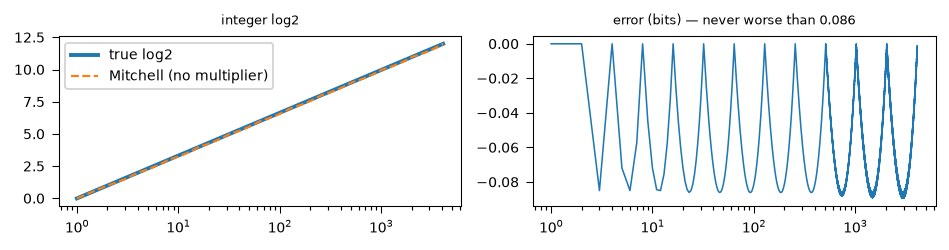

worst log2 error: 0.089 bits = 0.27 dB


In [16]:
def log2_mitchell(v):
    '''Integer log2, no multiplier: leading-one position + the mantissa bits.'''
    v = max(int(v), 1)
    e = v.bit_length() - 1                # priority encoder in hardware
    frac = ((v << 8) >> e) - 256          # barrel shift, then subtract
    return e + frac/256

vals = np.arange(1, 4096)
approx = np.array([log2_mitchell(v) for v in vals])
fig, ax = plt.subplots(1, 2, figsize=(6.7, 1.8))
ax[0].plot(vals, np.log2(vals), label="true log2", lw=2)
ax[0].plot(vals, approx, "--", label="Mitchell (no multiplier)")
ax[0].set_xscale("log"); ax[0].legend(); ax[0].set_title("integer log2")
ax[1].plot(vals, approx - np.log2(vals), lw=.8)
ax[1].set_xscale("log"); ax[1].set_title("error (bits) — never worse than 0.086")
plt.tight_layout(); plt.show()
print("worst log2 error: %.3f bits = %.2f dB" % (np.abs(approx - np.log2(vals)).max(), 3.01*np.abs(approx - np.log2(vals)).max()))

## Using the real thing

**Real voices, on the PC.** The *Audio Ladder* notebook's `audio_model.py` loads the Hillenbrand recordings
(139 speakers, mounted on Ed). Put it beside this notebook and `features_of` works unchanged:

```python
from audio_model import load, speakers          # a recording is float samples at 12 kHz, trimmed to the vowel
x = (load("m01iy")*32767).astype(np.int16)      # m01 says "ee"; ah, uw, aw are the other three
print(features_of(x).shape)
```

Enrol on one speaker (`m01`) and test on another (`m02`, `w01`): that is the experiment the demo probes are
made of, and section 5 of that notebook runs it for every rung.

**Your own voice, through the FPGA.** The templates the provided classifier needs are *not* made here: they
are captured from your own pipeline on the board with SignalTap (the *Enrolment with SignalTap* slide), so
that they carry your fixed-point choices exactly. The same capture trains the tree: `train_templates.py`
unpacks the `feature` column into integers, and `Tree.fit` takes those.

### Suggested build order for the FPGA

Do them one at a time and check each against the numbers in this notebook before moving on. Lesson 4 built
the biggest block; everything after it is small.

1. Window ROM in `window_function.sv` → compare your frames to `frames_of(x)*WIN`
2. FFT + |X|² (Lesson 4, done) → compare to `spectrum_of(x)`
3. Mel ROM + accumulate → compare to `S @ MEL.T`
4. Mitchell log2 → compare to `log2_mitchell`, then subtract the mean: **that is the HD feature vector**
5. Extras: the DCT ROM → compare to `mfcc_of(x)`, and/or paste in `vowel_tree.v`
6. The gate (R-A1, in front of all of it) → compare to `gate(x)`

### If accuracy is disappointing

Check in this order; it is almost always the first one.

1. Is the gate picking the right frames? Plot it, like in Step 7, and watch `enable` in SignalTap.
2. Are your recordings clipping, or too quiet? HEX1..0 should read well above the room.
3. Do you have enough data, and from the people who will speak at the demo?
4. Only then touch the features: the band edges, the number of Mel filters, `max_depth` 4–8.